# Precipitation

Este notebook separa dos flujos distintos:
- `daily`: GHCND `PRCP` para climatología, acumulados diarios y `daily_wet_spells`.
- `hourly`: solo estaciones y productos NOAA/NCEI verificados con resolución horaria o mejor para `hourly_storm_events`.

Regla clave: no usar un `dry-gap` de 6 horas con datos diarios.
Para datos diarios se usan secuencias húmedas diarias; para datos horarios se usa `6 h`.

Salidas principales:
- `data/processed/precipitation/station_availability/`
- `data/processed/precipitation/daily/`
- `data/processed/precipitation/hourly/`
- `data/processed/precipitation/events_daily/`
- `data/processed/precipitation/events_hourly/`


In [ ]:
import hashlib
import logging
import os
import time
from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from shapely import make_valid
from shapely.ops import unary_union

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))
plt.style.use('seaborn-v0_8-whitegrid')

logger = logging.getLogger('precipitation')
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()
INVENTORY_PATH = ROOT / 'data' / 'temporal' / 'noaa' / '4308211.csv'
NYC_BOUNDARY_PATH = ROOT / 'data' / 'spatial' / 'vector' / 'nyc_borough_boundary' / 'nybb.geojson'

OUTPUT_ROOT = ROOT / 'data' / 'processed' / 'precipitation'
AVAILABILITY_DIR = OUTPUT_ROOT / 'station_availability'
DAILY_DIR = OUTPUT_ROOT / 'daily'
HOURLY_DIR = OUTPUT_ROOT / 'hourly'
DAILY_EVENTS_DIR = OUTPUT_ROOT / 'events_daily'
HOURLY_EVENTS_DIR = OUTPUT_ROOT / 'events_hourly'
RAW_CACHE_DIR = ROOT / 'data' / 'temporal' / 'noaa' / 'cache'

for folder in (AVAILABILITY_DIR, DAILY_DIR, HOURLY_DIR, DAILY_EVENTS_DIR, HOURLY_EVENTS_DIR, RAW_CACHE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

NOAA_BASE_URL = 'https://www.ncei.noaa.gov/cdo-web/api/v2'
NOAA_TOKEN_ENV_NAMES = ('NOAA_CDO_TOKEN', 'NOAA_API_TOKEN')
DAILY_CANDIDATE_DATASETS = ['GHCND', 'LCD']
HOURLY_CANDIDATE_DATASETS = ['LCD']
START_DATE = '2010-01-01'
END_DATE = date.today().isoformat()
API_LIMIT = 1000
PROBE_LIMIT = 50
API_MAX_RETRIES = 5
API_RETRY_BACKOFF_SECONDS = 2.0
MIN_EVENT_MM = 1.1
DAILY_WET_GAP = pd.Timedelta(days=1)
HOURLY_DRY_GAP = pd.Timedelta(hours=6)
LOCAL_CRS = 'EPSG:2263'

PRECIP_DATATYPE_CACHE = {}
PROBE_CACHE = {}
FULL_CACHE = {}

TARGET_STATIONS = [
    'US1NJPS0012',
    'USC00283704',
    'USC00289187',
    'US1NJMN0010',
    'USC00066655',
    'US1NJMS0049',
    'US1NJPS0019',
    'USC00300961',
    'USC00287865',
    'USC00285503',
    'USC00302129',
    'USC00287079',
    'USC00306138',
]

def get_noaa_token() -> str | None:
    for name in NOAA_TOKEN_ENV_NAMES:
        token = os.getenv(name)
        if token:
            return token
    logger.warning('Falta el token de NOAA. Se usara cache local si existe; de lo contrario, la descarga quedara vacia.')
    return None


def station_aliases(station_code: str) -> list[str]:
    aliases = [f'GHCND:{station_code}', f'COOP:{station_code}', f'LCD:{station_code}', station_code]
    seen = set()
    ordered = []
    for alias in aliases:
        if alias not in seen:
            ordered.append(alias)
            seen.add(alias)
    return ordered


def request_cdo_json(endpoint: str, token: str, params: dict | None = None) -> dict:
    url = f'{NOAA_BASE_URL}/{endpoint.lstrip("/")}'
    headers = {'token': token}
    params = dict(params or {})
    for attempt in range(API_MAX_RETRIES + 1):
        response = requests.get(url, headers=headers, params=params, timeout=60)
        if response.status_code in {429, 500, 502, 503, 504} and attempt < API_MAX_RETRIES:
            wait_seconds = API_RETRY_BACKOFF_SECONDS * (2 ** attempt)
            logger.warning(
                'NOAA retry status=%s endpoint=%s attempt=%s/%s sleep=%.1fs',
                response.status_code,
                endpoint,
                attempt + 1,
                API_MAX_RETRIES + 1,
                wait_seconds,
            )
            time.sleep(wait_seconds)
            continue
        if response.status_code >= 400:
            body = response.text.strip().replace('\n', ' ')[:500]
            raise RuntimeError(f'Request failed for {url}: {response.status_code} {response.reason}. {body}')
        try:
            return response.json()
        except ValueError as exc:
            body = response.text.strip().replace('\n', ' ')[:500]
            raise RuntimeError(f'Invalid JSON from {url}: {body}') from exc
    raise RuntimeError(f'Unable to fetch {url}')


def build_cache_path(kind: str, dataset_id: str, datatype_id: str, station_id: str, start_date: str, end_date: str) -> Path:
    key = f'{kind}|{dataset_id}|{datatype_id}|{station_id}|{start_date}|{end_date}'
    digest = hashlib.sha1(key.encode('utf-8')).hexdigest()[:16]
    return RAW_CACHE_DIR / f'precip_{kind}_{digest}.csv'


def fetch_cdo_frame(
    token: str,
    dataset_id: str,
    datatype_id: str,
    station_id: str,
    start_date: str,
    end_date: str,
    limit: int,
    kind: str,
    force_refresh: bool = False,
) -> pd.DataFrame:
    cache_path = build_cache_path(kind, dataset_id, datatype_id, station_id, start_date, end_date)
    if cache_path.exists() and not force_refresh:
        frame = pd.read_csv(cache_path, low_memory=False)
        frame.attrs['record_count'] = len(frame)
        return frame

    if not token:
        logger.warning(
            'NOAA token missing; skipping fetch for dataset=%s datatype=%s station=%s',
            dataset_id,
            datatype_id,
            station_id,
        )
        empty = pd.DataFrame()
        empty.attrs['record_count'] = 0
        return empty

    rows = []
    offset = 0
    total_count = None
    while True:
        payload = request_cdo_json(
            'data',
            token,
            params={
                'datasetid': dataset_id,
                'datatypeid': datatype_id,
                'stationid': station_id,
                'startdate': start_date,
                'enddate': end_date,
                'units': 'metric',
                'limit': limit,
                'offset': offset,
            },
        )
        batch = payload.get('results', [])
        if total_count is None:
            total_count = payload.get('metadata', {}).get('resultset', {}).get('count')
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < limit:
            break
        offset += limit

    frame = pd.DataFrame.from_records(rows)
    if not frame.empty:
        frame.to_csv(cache_path, index=False)
    frame.attrs['record_count'] = int(total_count) if total_count is not None else len(frame)
    return frame


def prepare_cdo_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if out.empty:
        return pd.DataFrame(columns=['timestamp', 'source_station_id', 'precip_mm'])
    rename_map = {}
    if 'date' in out.columns and 'timestamp' not in out.columns:
        rename_map['date'] = 'timestamp'
    if 'station' in out.columns and 'source_station_id' not in out.columns:
        rename_map['station'] = 'source_station_id'
    if 'value' in out.columns and 'precip_mm' not in out.columns:
        rename_map['value'] = 'precip_mm'
    out = out.rename(columns=rename_map)
    if 'timestamp' not in out.columns or 'precip_mm' not in out.columns:
        raise ValueError(f'La respuesta NOAA no tiene columnas compatibles: {sorted(out.columns)}')
    out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce')
    raw = out['precip_mm'].astype('string')
    trace_mask = raw.str.upper().eq('T')
    out['precip_mm'] = pd.to_numeric(raw, errors='coerce')
    out.loc[trace_mask, 'precip_mm'] = 0.0
    out = out.dropna(subset=['timestamp', 'precip_mm']).copy()
    out = out.loc[out['precip_mm'] >= 0].copy()
    if 'source_station_id' not in out.columns:
        out['source_station_id'] = pd.NA
    out['source_station_id'] = out['source_station_id'].astype('string')
    return out


def infer_temporal_resolution(timestamps, dataset_id: str | None = None, datatype_id: str | None = None) -> str:
    ts = pd.Series(pd.to_datetime(timestamps, errors='coerce')).dropna().sort_values().drop_duplicates()
    if len(ts) < 2:
        if dataset_id == 'GHCND' and datatype_id == 'PRCP':
            return 'daily'
        if datatype_id and str(datatype_id).upper() == 'HPCP':
            return 'hourly'
        return 'unknown'
    diffs = ts.diff().dropna()
    diffs = diffs[diffs > pd.Timedelta(0)]
    if diffs.empty:
        return 'unknown'
    min_delta = diffs.min()
    if min_delta < pd.Timedelta(hours=1):
        return 'subhourly'
    if min_delta < pd.Timedelta(days=1):
        return 'hourly'
    return 'daily'


def discover_precip_datatypes(dataset_id: str, token: str | None = None) -> list[str]:
    """Return explicit precipitation datatype candidates without any extra API probing."""
    if dataset_id == 'GHCND':
        return ['PRCP']
    if dataset_id == 'LCD':
        return ['HPCP', 'PRCP']
    return []

def probe_station_source(
    token: str,
    dataset_id: str,
    datatype_id: str,
    anchor_station_id: str,
    station_name: str,
    aliases: list[str],
    required_resolution: str,
) -> dict | None:
    cache_key = (dataset_id, datatype_id, anchor_station_id, required_resolution, tuple(aliases))
    if cache_key in PROBE_CACHE:
        return PROBE_CACHE[cache_key]
    if not token:
        PROBE_CACHE[cache_key] = None
        return None
    if not token:
        PROBE_CACHE[cache_key] = None
        return None
    if not token:
        PROBE_CACHE[cache_key] = None
        return None
    for alias in aliases:
        try:
            raw = fetch_cdo_frame(
                token=token,
                dataset_id=dataset_id,
                datatype_id=datatype_id,
                station_id=alias,
                start_date=START_DATE,
                end_date=END_DATE,
                limit=PROBE_LIMIT,
                kind='probe',
            )
        except Exception as exc:
            logger.info(
                'Probe failed dataset=%s datatype=%s station=%s alias=%s reason=%s',
                dataset_id,
                datatype_id,
                anchor_station_id,
                alias,
                exc,
            )
            continue
        if raw.empty:
            continue
        prepared = prepare_cdo_frame(raw)
        if prepared.empty:
            continue
        resolution = infer_temporal_resolution(prepared['timestamp'], dataset_id=dataset_id, datatype_id=datatype_id)
        if required_resolution == 'daily' and resolution != 'daily':
            continue
        if required_resolution == 'hourly' and resolution not in {'hourly', 'subhourly'}:
            continue
        result = {
            'station_id': anchor_station_id,
            'station_name': station_name,
            'source_dataset': dataset_id,
            'data_type': datatype_id,
            'source_station_id': str(prepared['source_station_id'].iloc[0]) if 'source_station_id' in prepared.columns and not prepared.empty else alias,
            'source_alias_used': alias,
            'temporal_resolution': resolution,
            'record_count_probe': int(raw.attrs.get('record_count', len(prepared))),
            'sample_start': prepared['timestamp'].min(),
            'sample_end': prepared['timestamp'].max(),
        }
        PROBE_CACHE[cache_key] = result
        return result
    PROBE_CACHE[cache_key] = None
    return None


def select_precip_source(
    token: str | None,
    station_row: pd.Series,
    kind: str,
) -> dict | None:
    station_id = str(station_row['station_id'])
    station_name = str(station_row['station_name'])
    aliases = station_aliases(station_id)
    if kind == 'daily':
        candidates = [('GHCND', 'PRCP'), ('LCD', 'PRCP')]
        required_resolution = 'daily'
    elif kind == 'hourly':
        candidates = [('LCD', 'HPCP')]
        required_resolution = 'hourly'
    else:
        raise ValueError(f'Unknown kind: {kind}')
    for dataset_id, datatype_id in candidates:
        probe = probe_station_source(
            token=token,
            dataset_id=dataset_id,
            datatype_id=datatype_id,
            anchor_station_id=station_id,
            station_name=station_name,
            aliases=aliases,
            required_resolution=required_resolution,
        )
        if probe is not None:
            probe['source_kind'] = kind
            return probe
    return None

def audit_station_availability(station_row: pd.Series, token: str) -> dict:
    daily = select_precip_source(token, station_row, 'daily')
    hourly = select_precip_source(token, station_row, 'hourly')
    selected = hourly or daily
    if selected is None:
        station_type = 'no_precip_found'
        selected_kind = 'none'
    elif selected['temporal_resolution'] == 'subhourly':
        station_type = 'subhourly_available'
        selected_kind = 'hourly'
    elif selected['temporal_resolution'] == 'hourly':
        station_type = 'hourly_available'
        selected_kind = 'hourly'
    else:
        station_type = 'daily_only'
        selected_kind = 'daily'

    notes = []
    if daily:
        notes.append(f"daily={daily['source_dataset']}:{daily['data_type']}:{daily['source_station_id']}")
    else:
        notes.append('daily_not_found')
    if hourly:
        notes.append(f"hourly={hourly['source_dataset']}:{hourly['data_type']}:{hourly['source_station_id']}")
    else:
        notes.append('hourly_not_found')
    if selected is None:
        notes.append('excluded_no_precip')

    return {
        'station_id': str(station_row['station_id']),
        'station_name': str(station_row['station_name']),
        'station_type_prelim': str(station_row['station_type_prelim']),
        'station_type': station_type,
        'latitude': float(station_row['latitude']),
        'longitude': float(station_row['longitude']),
        'selected_source_kind': selected_kind,
        'source_dataset': selected['source_dataset'] if selected else pd.NA,
        'data_type': selected['data_type'] if selected else pd.NA,
        'temporal_resolution': selected['temporal_resolution'] if selected else pd.NA,
        'source_station_id': selected['source_station_id'] if selected else pd.NA,
        'source_alias_used': selected['source_alias_used'] if selected else pd.NA,
        'record_count': 0,
        'start_date': pd.NA,
        'end_date': pd.NA,
        'daily_source_dataset': daily['source_dataset'] if daily else pd.NA,
        'daily_data_type': daily['data_type'] if daily else pd.NA,
        'daily_source_station_id': daily['source_station_id'] if daily else pd.NA,
        'daily_probe_resolution': daily['temporal_resolution'] if daily else pd.NA,
        'daily_record_count_probe': daily['record_count_probe'] if daily else 0,
        'hourly_source_dataset': hourly['source_dataset'] if hourly else pd.NA,
        'hourly_data_type': hourly['data_type'] if hourly else pd.NA,
        'hourly_source_station_id': hourly['source_station_id'] if hourly else pd.NA,
        'hourly_probe_resolution': hourly['temporal_resolution'] if hourly else pd.NA,
        'hourly_record_count_probe': hourly['record_count_probe'] if hourly else 0,
        'has_daily_prcp': bool(daily),
        'has_hourly_prcp': bool(hourly),
        'has_subhourly_prcp': bool(hourly and hourly['temporal_resolution'] == 'subhourly'),
        'selected_for_daily_analysis': bool(daily),
        'selected_for_event_analysis': bool(hourly),
        'notes': '; '.join(notes),
        'daily_sample_start': daily['sample_start'] if daily else pd.NA,
        'daily_sample_end': daily['sample_end'] if daily else pd.NA,
        'hourly_sample_start': hourly['sample_start'] if hourly else pd.NA,
        'hourly_sample_end': hourly['sample_end'] if hourly else pd.NA,
    }


def load_station_inventory(target_stations: list[str]) -> pd.DataFrame:
    frame = pd.read_csv(INVENTORY_PATH, low_memory=False)
    required = {'STATION', 'NAME', 'LATITUDE', 'LONGITUDE'}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'El inventario NOAA no tiene las columnas esperadas: {sorted(missing)}')
    frame = frame.drop_duplicates('STATION').copy()
    frame = frame.rename(
        columns={
            'STATION': 'station_id',
            'NAME': 'station_name',
            'LATITUDE': 'latitude',
            'LONGITUDE': 'longitude',
        }
    )
    frame['station_id'] = frame['station_id'].astype('string')
    frame['station_name'] = frame['station_name'].astype('string')
    frame['latitude'] = pd.to_numeric(frame['latitude'], errors='coerce')
    frame['longitude'] = pd.to_numeric(frame['longitude'], errors='coerce')
    frame = frame.dropna(subset=['station_id', 'latitude', 'longitude']).copy()
    frame['station_type_prelim'] = np.where(
        frame['station_id'].str.startswith('US1'),
        'probable_daily_only',
        'daily_available_hourly_possible',
    )
    frame = frame.loc[frame['station_id'].isin(target_stations)].copy()
    missing_targets = sorted(set(target_stations) - set(frame['station_id']))
    if missing_targets:
        logger.warning('Station ids not found in inventory: %s', ', '.join(missing_targets))
    frame = frame.sort_values('station_id').reset_index(drop=True)
    return frame


def load_nyc_boundary() -> tuple[gpd.GeoDataFrame, object]:
    boroughs = gpd.read_file(NYC_BOUNDARY_PATH)
    boroughs = boroughs.copy()
    boroughs['geometry'] = boroughs.geometry.apply(make_valid)
    if boroughs.crs is None:
        boroughs = boroughs.set_crs('EPSG:4326')
    city = unary_union(boroughs.geometry)
    return boroughs, city


def make_station_gdf(frame: pd.DataFrame, crs: str = 'EPSG:4326') -> gpd.GeoDataFrame:
    return gpd.GeoDataFrame(
        frame.copy(),
        geometry=gpd.points_from_xy(frame['longitude'], frame['latitude']),
        crs=crs,
    )


def set_map_extent(ax, geom, pad: float = 0.05) -> None:
    minx, miny, maxx, maxy = geom.bounds
    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)


def validate_series(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    if frame.empty:
        return frame
    frame = frame.dropna(subset=['station_id', 'timestamp', 'precip_mm']).copy()
    dup_mask = frame.duplicated(subset=['station_id', 'timestamp'])
    if dup_mask.any():
        logger.warning('%s: removed %s duplicate timestamps', label, int(dup_mask.sum()))
        frame = frame.loc[~dup_mask].copy()
    frame = frame.sort_values(['station_id', 'timestamp']).reset_index(drop=True)
    bad = frame['precip_mm'] < 0
    if bad.any():
        logger.warning('%s: removed %s negative precipitation values', label, int(bad.sum()))
        frame = frame.loc[~bad].copy()
    return frame


def finalize_record_frame(
    frame: pd.DataFrame,
    anchor_station_id: str,
    station_name: str,
    source_dataset: str,
    data_type: str,
    source_station_id: str,
    analysis_kind: str,
) -> pd.DataFrame:
    out = prepare_cdo_frame(frame)
    if out.empty:
        return pd.DataFrame(
            columns=[
                'station_id',
                'station_name',
                'source_station_id',
                'source_dataset',
                'data_type',
                'analysis_kind',
                'temporal_resolution',
                'timestamp',
                'precip_mm',
            ]
        )
    out['station_id'] = anchor_station_id
    out['station_name'] = station_name
    out['source_station_id'] = out['source_station_id'].fillna(source_station_id)
    out['source_dataset'] = source_dataset
    out['data_type'] = data_type
    out['analysis_kind'] = analysis_kind
    out['temporal_resolution'] = infer_temporal_resolution(out['timestamp'], dataset_id=source_dataset, datatype_id=data_type)
    out = out.drop_duplicates(subset=['station_id', 'timestamp']).copy()
    out = out.sort_values(['station_id', 'timestamp']).reset_index(drop=True)
    out['year'] = out['timestamp'].dt.year
    out['month'] = out['timestamp'].dt.month
    out['day'] = out['timestamp'].dt.day
    return out


def build_precip_event_summary(
    records: pd.DataFrame,
    event_label: str,
    gap: pd.Timedelta,
    min_total_mm: float,
) -> pd.DataFrame:
    columns = [
        'station_id',
        'station_name',
        'event_id',
        'event_uid',
        'event_kind',
        'start',
        'end',
        'duration_hours',
        'precip_mm',
        'mean_intensity_mm_per_hr',
        'n_records',
        'wet_records',
        'source_dataset',
        'data_type',
        'temporal_resolution',
    ]
    if records.empty:
        return pd.DataFrame(columns=columns)
    summaries = []
    for (station_id, station_name, source_dataset, data_type, temporal_resolution), group in records.groupby(
        ['station_id', 'station_name', 'source_dataset', 'data_type', 'temporal_resolution'],
        dropna=False,
        sort=False,
    ):
        group = group.sort_values('timestamp').copy()
        wet = group.loc[group['precip_mm'] > 0, ['timestamp', 'precip_mm']].copy()
        if wet.empty:
            continue
        wet['time_diff'] = wet['timestamp'].diff()
        wet['event_id'] = (wet['time_diff'].isna() | (wet['time_diff'] > gap)).cumsum().astype(int)
        for event_id, wet_group in wet.groupby('event_id', sort=True):
            start = wet_group['timestamp'].min()
            end = wet_group['timestamp'].max()
            event_frame = group.loc[(group['timestamp'] >= start) & (group['timestamp'] <= end)].copy()
            if event_frame.empty:
                continue
            total_mm = float(event_frame['precip_mm'].sum())
            if total_mm < min_total_mm:
                continue
            step = event_frame['timestamp'].sort_values().diff().dropna()
            if step.empty:
                sample_step = gap if event_label == 'daily_wet_spell' else pd.Timedelta(hours=1)
            else:
                sample_step = step[step > pd.Timedelta(0)].min()
                if pd.isna(sample_step):
                    sample_step = gap if event_label == 'daily_wet_spell' else pd.Timedelta(hours=1)
            duration_hours = max(((end - start) + sample_step).total_seconds() / 3600.0, sample_step.total_seconds() / 3600.0)
            event_uid = f'{station_id}_{event_label}_{int(event_id):04d}'
            summaries.append(
                {
                    'station_id': station_id,
                    'station_name': station_name,
                    'event_id': int(event_id),
                    'event_uid': event_uid,
                    'event_kind': event_label,
                    'start': start,
                    'end': end,
                    'duration_hours': duration_hours,
                    'precip_mm': total_mm,
                    'mean_intensity_mm_per_hr': total_mm / duration_hours if duration_hours > 0 else np.nan,
                    'n_records': int(len(event_frame)),
                    'wet_records': int(len(wet_group)),
                    'source_dataset': source_dataset,
                    'data_type': data_type,
                    'temporal_resolution': temporal_resolution,
                }
            )
    if not summaries:
        return pd.DataFrame(columns=columns)
    frame = pd.DataFrame.from_records(summaries)
    frame = frame.sort_values(['station_id', 'start', 'event_id'], kind='stable').reset_index(drop=True)
    return frame[columns]


def summarize_station_records(frame: pd.DataFrame) -> pd.DataFrame:
    columns = [
        'station_id',
        'station_name',
        'source_dataset',
        'data_type',
        'analysis_kind',
        'start',
        'end',
        'record_count',
        'wet_records',
        'total_precip_mm',
        'mean_precip_mm',
    ]
    if frame.empty:
        return pd.DataFrame(columns=columns)
    summary = (
        frame.groupby(['station_id', 'station_name', 'source_dataset', 'data_type', 'analysis_kind'], dropna=False)
        .agg(
            start=('timestamp', 'min'),
            end=('timestamp', 'max'),
            record_count=('timestamp', 'size'),
            wet_records=('precip_mm', lambda s: int((s > 0).sum())),
            total_precip_mm=('precip_mm', 'sum'),
            mean_precip_mm=('precip_mm', 'mean'),
        )
        .reset_index()
    )
    return summary[columns]


def build_final_availability_table(probe_frame: pd.DataFrame, daily_records: pd.DataFrame, hourly_records: pd.DataFrame) -> pd.DataFrame:
    frame = probe_frame.copy()
    daily_summary = summarize_station_records(daily_records)
    hourly_summary = summarize_station_records(hourly_records)

    daily_summary = daily_summary.rename(
        columns={
            'start': 'daily_start_date',
            'end': 'daily_end_date',
            'record_count': 'daily_record_count',
            'wet_records': 'daily_wet_records',
            'total_precip_mm': 'daily_total_precip_mm',
            'mean_precip_mm': 'daily_mean_precip_mm',
        }
    )
    hourly_summary = hourly_summary.rename(
        columns={
            'start': 'hourly_start_date',
            'end': 'hourly_end_date',
            'record_count': 'hourly_record_count',
            'wet_records': 'hourly_wet_records',
            'total_precip_mm': 'hourly_total_precip_mm',
            'mean_precip_mm': 'hourly_mean_precip_mm',
        }
    )

    frame = frame.merge(daily_summary, on=['station_id', 'station_name'], how='left')
    frame = frame.merge(hourly_summary, on=['station_id', 'station_name'], how='left')

    frame['has_daily_prcp'] = frame['daily_record_count'].fillna(0).astype(int) > 0
    frame['has_hourly_prcp'] = frame['hourly_record_count'].fillna(0).astype(int) > 0
    frame['has_subhourly_prcp'] = frame['hourly_probe_resolution'].eq('subhourly')
    frame['selected_for_daily_analysis'] = frame['has_daily_prcp']
    frame['selected_for_event_analysis'] = frame['has_hourly_prcp']

    selected_kind = frame['selected_source_kind'].fillna('none')
    mask_hourly = selected_kind.eq('hourly')
    mask_daily = selected_kind.eq('daily')

    frame['source_dataset'] = np.where(mask_hourly, frame['hourly_source_dataset'], np.where(mask_daily, frame['daily_source_dataset'], pd.NA))
    frame['data_type'] = np.where(mask_hourly, frame['hourly_data_type'], np.where(mask_daily, frame['daily_data_type'], pd.NA))
    frame['temporal_resolution'] = np.where(mask_hourly, frame['hourly_probe_resolution'], np.where(mask_daily, frame['daily_probe_resolution'], pd.NA))
    frame['source_station_id'] = np.where(mask_hourly, frame['hourly_source_station_id'], np.where(mask_daily, frame['daily_source_station_id'], pd.NA))
    frame['record_count'] = np.where(mask_hourly, frame['hourly_record_count'], np.where(mask_daily, frame['daily_record_count'], 0))
    frame['record_count'] = pd.to_numeric(frame['record_count'], errors='coerce').fillna(0).astype('int64')
    frame['start_date'] = np.where(mask_hourly, frame['hourly_start_date'], np.where(mask_daily, frame['daily_start_date'], pd.NA))
    frame['end_date'] = np.where(mask_hourly, frame['hourly_end_date'], np.where(mask_daily, frame['daily_end_date'], pd.NA))

    for column in ['start_date', 'end_date', 'daily_start_date', 'daily_end_date', 'hourly_start_date', 'hourly_end_date']:
        if column in frame.columns:
            frame[column] = pd.to_datetime(frame[column], errors='coerce').dt.strftime('%Y-%m-%dT%H:%M:%S')

    ordered = [
        'station_id',
        'station_name',
        'station_type_prelim',
        'station_type',
        'latitude',
        'longitude',
        'selected_source_kind',
        'source_dataset',
        'data_type',
        'temporal_resolution',
        'source_station_id',
        'source_alias_used',
        'start_date',
        'end_date',
        'record_count',
        'has_daily_prcp',
        'has_hourly_prcp',
        'has_subhourly_prcp',
        'selected_for_daily_analysis',
        'selected_for_event_analysis',
        'daily_source_dataset',
        'daily_data_type',
        'daily_source_station_id',
        'daily_probe_resolution',
        'daily_record_count_probe',
        'daily_start_date',
        'daily_end_date',
        'daily_record_count',
        'daily_wet_records',
        'daily_total_precip_mm',
        'daily_mean_precip_mm',
        'hourly_source_dataset',
        'hourly_data_type',
        'hourly_source_station_id',
        'hourly_probe_resolution',
        'hourly_record_count_probe',
        'hourly_start_date',
        'hourly_end_date',
        'hourly_record_count',
        'hourly_wet_records',
        'hourly_total_precip_mm',
        'hourly_mean_precip_mm',
        'notes',
    ]
    for column in ordered:
        if column not in frame.columns:
            frame[column] = pd.NA
    return frame[ordered].sort_values('station_id').reset_index(drop=True)


## 1. Station availability audit

`US1*` stations are treated as probable daily-only candidates.
`USC*` stations are treated as preliminary daily + hourly candidates, but the notebook verifies actual availability per station and per dataset.

The audit keeps daily and hourly sources separate and only marks `hourly_storm_events` when a verified sub-daily or hourly precip source exists.


[INFO] Probe failed dataset=GHCND datatype=PRCP station=US1NJMN0010 alias=GHCND:US1NJMN0010 reason=Request failed for https://www.ncei.noaa.gov/cdo-web/api/v2/data: 400 . <?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><statusCode>400</statusCode><userMessage>There was an error with the request.</userMessage><developerMessage>The date range must be less than 1 year.</developerMessage></response>
[INFO] Probe failed dataset=GHCND datatype=PRCP station=US1NJMN0010 alias=COOP:US1NJMN0010 reason=Request failed for https://www.ncei.noaa.gov/cdo-web/api/v2/data: 400 . <?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><statusCode>400</statusCode><userMessage>There was an error with the request.</userMessage><developerMessage>The date range must be less than 1 year.</developerMessage></response>
[INFO] Probe failed dataset=GHCND datatype=PRCP station=US1NJMN0010 alias=LCD:US1NJMN0010 reason=Request failed for https://www.ncei.noaa.gov/cdo-web/api/v2/data: 400 . 

Estaciones evaluadas: 13
Daily verificadas: 0
Hourly verificadas: 0
Subhourly verificadas: 0


,station_id,station_type_prelim,station_type,selected_source_kind,source_dataset,data_type,temporal_resolution,selected_for_daily_analysis,selected_for_event_analysis,notes
0,US1NJMN0010,probable_daily_only,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
1,US1NJMS0049,probable_daily_only,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
2,US1NJPS0012,probable_daily_only,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
3,US1NJPS0019,probable_daily_only,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
4,USC00066655,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
5,USC00283704,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
6,USC00285503,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
7,USC00287079,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
8,USC00287865,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...
9,USC00289187,daily_available_hourly_possible,no_precip_found,none,<NA>,<NA>,<NA>,False,False,daily_not_found; hourly_not_found; excluded_no...


/tmp/ipykernel_246180/1950124667.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  set_map_extent(ax, boroughs_plot.unary_union, pad=0.05)


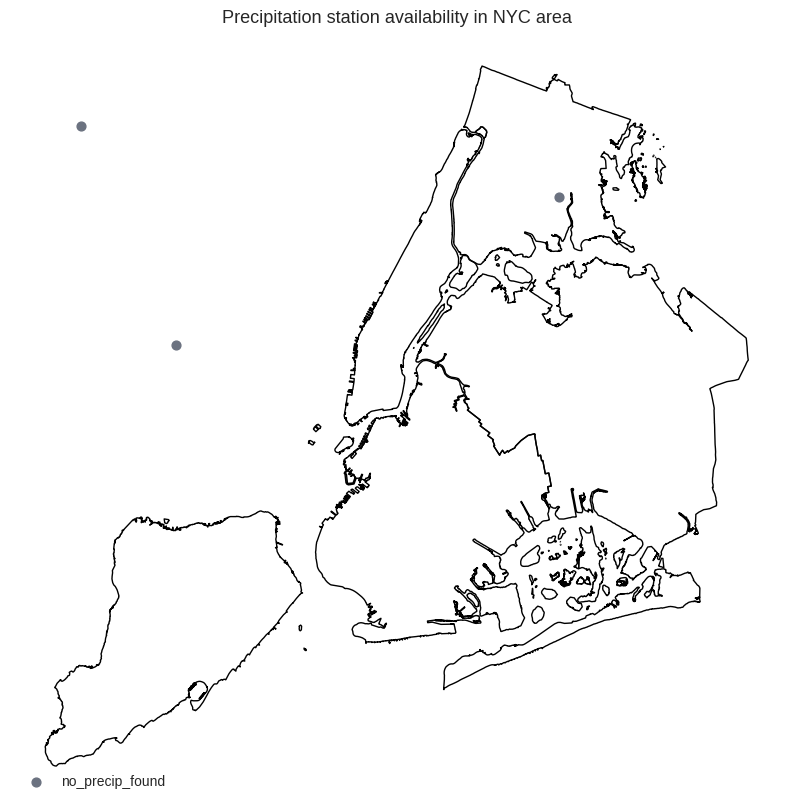

In [7]:
token = get_noaa_token()
nyc_boroughs, nyc_union = load_nyc_boundary()
station_inventory = load_station_inventory(TARGET_STATIONS)

if station_inventory.empty:
    raise ValueError('No se encontraron estaciones objetivo en el inventario NOAA.')

availability_probe = pd.DataFrame([
    audit_station_availability(row, token)
    for row in station_inventory.to_dict('records')
])

availability_points = make_station_gdf(availability_probe, crs='EPSG:4326')
availability_points_local = availability_points.to_crs(LOCAL_CRS)

print(f'Estaciones evaluadas: {len(availability_probe):,}')
print(f'Daily verificadas: {int(availability_probe["selected_for_daily_analysis"].sum()):,}')
print(f'Hourly verificadas: {int(availability_probe["selected_for_event_analysis"].sum()):,}')
print(f'Subhourly verificadas: {int(availability_probe["has_subhourly_prcp"].sum()):,}')

display(
    availability_probe[
        [
            'station_id',
            'station_type_prelim',
            'station_type',
            'selected_source_kind',
            'source_dataset',
            'data_type',
            'temporal_resolution',
            'selected_for_daily_analysis',
            'selected_for_event_analysis',
            'notes',
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10, 10))
boroughs_plot = nyc_boroughs.to_crs(availability_points.crs)
boroughs_plot.boundary.plot(ax=ax, color='black', linewidth=1)
colors = {
    'daily_only': '#2563eb',
    'hourly_available': '#d97706',
    'subhourly_available': '#dc2626',
    'no_precip_found': '#6b7280',
}
for station_type, group in availability_points.groupby('station_type'):
    group.plot(ax=ax, color=colors.get(station_type, '#6b7280'), markersize=40, label=station_type)
set_map_extent(ax, boroughs_plot.unary_union, pad=0.05)
ax.set_title('Precipitation station availability in NYC area', fontsize=13)
ax.set_axis_off()
ax.legend(frameon=False, loc='lower left')
plt.show()


## 2. Daily pipeline

This path uses daily precipitation records for climatology, daily accumulations, monthly and annual summaries, and daily wet-spell sequences.

It does **not** use a 6-hour storm gap. The event label is `daily_wet_spell`.


In [8]:
def fetch_selected_series(selection: pd.DataFrame, kind: str, token: str) -> pd.DataFrame:
    frames = []
    for row in selection.to_dict('records'):
        source_dataset = row[f'{kind}_source_dataset']
        data_type = row[f'{kind}_data_type']
        source_station_id = row[f'{kind}_source_station_id']
        if pd.isna(source_dataset) or pd.isna(data_type) or pd.isna(source_station_id):
            continue
        raw = fetch_cdo_frame(
            token=token,
            dataset_id=str(source_dataset),
            datatype_id=str(data_type),
            station_id=str(source_station_id),
            start_date=START_DATE,
            end_date=END_DATE,
            limit=API_LIMIT,
            kind=kind,
        )
        if raw.empty:
            logger.warning('%s: no data fetched for station=%s dataset=%s datatype=%s', kind, row['station_id'], source_dataset, data_type)
            continue
        frame = finalize_record_frame(
            raw,
            anchor_station_id=row['station_id'],
            station_name=row['station_name'],
            source_dataset=str(source_dataset),
            data_type=str(data_type),
            source_station_id=str(source_station_id),
            analysis_kind=kind,
        )
        frames.append(frame)
    if not frames:
        return pd.DataFrame(
            columns=[
                'station_id', 'station_name', 'source_station_id', 'source_dataset',
                'data_type', 'analysis_kind', 'temporal_resolution', 'timestamp', 'precip_mm'
            ]
        )
    frame = pd.concat(frames, ignore_index=True)
    frame = validate_series(frame, f'{kind}_records')
    return frame


daily_selection = availability_probe.loc[availability_probe['selected_for_daily_analysis']].copy()
daily_records = fetch_selected_series(daily_selection, 'daily', token) if not daily_selection.empty else pd.DataFrame(
    columns=['station_id', 'station_name', 'source_station_id', 'source_dataset', 'data_type', 'analysis_kind', 'temporal_resolution', 'timestamp', 'precip_mm']
)

daily_path = DAILY_DIR / 'daily_precipitation_records.csv'
daily_records.to_csv(daily_path, index=False)

daily_station_summary = summarize_station_records(daily_records)
daily_station_summary.to_csv(DAILY_DIR / 'daily_station_summary.csv', index=False)

if not daily_records.empty:
    daily_monthly_summary = (
        daily_records.assign(period=daily_records['timestamp'].dt.to_period('M').astype(str))
        .groupby(['station_id', 'station_name', 'period'], dropna=False)
        .agg(
            total_precip_mm=('precip_mm', 'sum'),
            wet_days=('precip_mm', lambda s: int((s > 0).sum())),
            mean_precip_mm=('precip_mm', 'mean'),
        )
        .reset_index()
    )
    daily_annual_summary = (
        daily_records.assign(year=daily_records['timestamp'].dt.year)
        .groupby(['station_id', 'station_name', 'year'], dropna=False)
        .agg(
            total_precip_mm=('precip_mm', 'sum'),
            wet_days=('precip_mm', lambda s: int((s > 0).sum())),
            mean_precip_mm=('precip_mm', 'mean'),
        )
        .reset_index()
    )
else:
    daily_monthly_summary = pd.DataFrame(columns=['station_id', 'station_name', 'period', 'total_precip_mm', 'wet_days', 'mean_precip_mm'])
    daily_annual_summary = pd.DataFrame(columns=['station_id', 'station_name', 'year', 'total_precip_mm', 'wet_days', 'mean_precip_mm'])

daily_monthly_summary.to_csv(DAILY_DIR / 'daily_monthly_summary.csv', index=False)
daily_annual_summary.to_csv(DAILY_DIR / 'daily_annual_summary.csv', index=False)

daily_wet_spell_events = build_precip_event_summary(
    daily_records,
    event_label='daily_wet_spell',
    gap=DAILY_WET_GAP,
    min_total_mm=MIN_EVENT_MM,
)
daily_wet_spell_events.to_csv(DAILY_EVENTS_DIR / 'daily_wet_spell_events.csv', index=False)

print(f'Daily records: {len(daily_records):,}')
print(f'Daily wet spells: {len(daily_wet_spell_events):,}')
display(daily_station_summary.sort_values('record_count', ascending=False).head(10))
display(daily_monthly_summary.head(10))
display(daily_annual_summary.head(10))
display(daily_wet_spell_events.head(10))


Daily records: 0
Daily wet spells: 0


,station_id,station_name,source_dataset,data_type,analysis_kind,start,end,record_count,wet_records,total_precip_mm,mean_precip_mm


,station_id,station_name,period,total_precip_mm,wet_days,mean_precip_mm


,station_id,station_name,year,total_precip_mm,wet_days,mean_precip_mm


,station_id,station_name,event_id,event_uid,event_kind,start,end,duration_hours,precip_mm,mean_intensity_mm_per_hr,n_records,wet_records,source_dataset,data_type,temporal_resolution


## 3. Hourly / sub-daily pipeline

Only stations and products that actually return hourly or sub-hourly precipitation are used here.

If no hourly source is verified, the notebook keeps the daily outputs and skips storm-event detection without failing.


In [9]:
hourly_selection = availability_probe.loc[availability_probe['selected_for_event_analysis']].copy()
hourly_records = fetch_selected_series(hourly_selection, 'hourly', token) if not hourly_selection.empty else pd.DataFrame(
    columns=['station_id', 'station_name', 'source_station_id', 'source_dataset', 'data_type', 'analysis_kind', 'temporal_resolution', 'timestamp', 'precip_mm']
)

hourly_path = HOURLY_DIR / 'hourly_precipitation_records.csv'
hourly_records.to_csv(hourly_path, index=False)

hourly_station_summary = summarize_station_records(hourly_records)
hourly_station_summary.to_csv(HOURLY_DIR / 'hourly_station_summary.csv', index=False)

if hourly_records.empty:
    logger.warning('No hourly precipitation records were verified. Hourly storm-event detection skipped.')
    hourly_storm_events = pd.DataFrame(
        columns=[
            'station_id', 'station_name', 'event_id', 'event_uid', 'event_kind', 'start', 'end',
            'duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records', 'wet_records',
            'source_dataset', 'data_type', 'temporal_resolution',
        ]
    )
else:
    hourly_storm_events = build_precip_event_summary(
        hourly_records,
        event_label='hourly_storm_event',
        gap=HOURLY_DRY_GAP,
        min_total_mm=MIN_EVENT_MM,
    )

hourly_storm_events.to_csv(HOURLY_EVENTS_DIR / 'hourly_storm_events.csv', index=False)

print(f'Hourly records: {len(hourly_records):,}')
print(f'Hourly storm events: {len(hourly_storm_events):,}')
display(hourly_station_summary.sort_values('record_count', ascending=False).head(10))
display(hourly_storm_events.head(10))


[WARNING] No hourly precipitation records were verified. Hourly storm-event detection skipped.


Hourly records: 0
Hourly storm events: 0


,station_id,station_name,source_dataset,data_type,analysis_kind,start,end,record_count,wet_records,total_precip_mm,mean_precip_mm


,station_id,station_name,event_id,event_uid,event_kind,start,end,duration_hours,precip_mm,mean_intensity_mm_per_hr,n_records,wet_records,source_dataset,data_type,temporal_resolution


## 4. Final availability table and summary

The final availability table merges the verified selection, the full daily/hourly record summaries, and the geospatial station points.


Availability table saved: /home/map10194/Documents/urban-flood-stress/data/processed/precipitation/station_availability/station_precipitation_availability.csv
Availability GeoPackage saved: /home/map10194/Documents/urban-flood-stress/data/processed/precipitation/station_availability/station_precipitation_availability.gpkg
Projected GeoPackage saved: /home/map10194/Documents/urban-flood-stress/data/processed/precipitation/station_availability/station_precipitation_availability_projected.gpkg
Stations evaluated: 13
Daily-only stations: 0
Hourly stations: 0
Subhourly stations: 0
Daily analysis stations: none
Event analysis stations: none


,station_id,station_type,source_dataset,data_type,temporal_resolution,start_date,end_date,record_count,selected_for_daily_analysis,selected_for_event_analysis,notes
0,US1NJMN0010,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
1,US1NJMS0049,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
2,US1NJPS0012,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
3,US1NJPS0019,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
4,USC00066655,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
5,USC00283704,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
6,USC00285503,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
7,USC00287079,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
8,USC00287865,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...
9,USC00289187,no_precip_found,<NA>,<NA>,<NA>,NaN,NaN,0,False,False,daily_not_found; hourly_not_found; excluded_no...


/tmp/ipykernel_246180/1141934230.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  set_map_extent(axes[1], boroughs_plot.unary_union, pad=0.05)


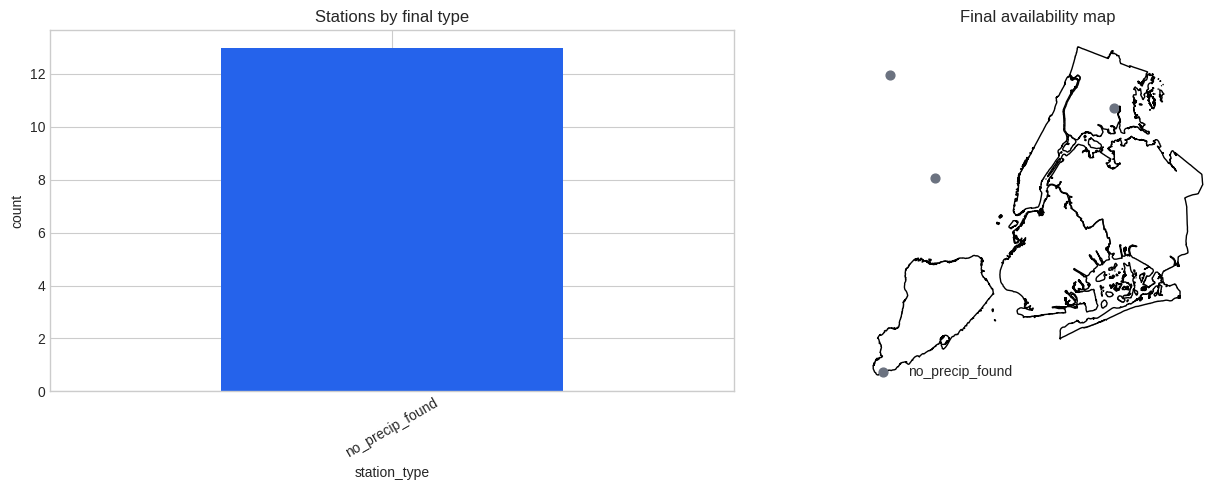

No hourly storm-event analysis was possible for the selected stations.


In [10]:
final_availability = build_final_availability_table(availability_probe, daily_records, hourly_records)
final_availability_gdf = make_station_gdf(final_availability, crs='EPSG:4326')
final_availability_local = final_availability_gdf.to_crs(LOCAL_CRS)

availability_csv = AVAILABILITY_DIR / 'station_precipitation_availability.csv'
availability_gpkg = AVAILABILITY_DIR / 'station_precipitation_availability.gpkg'
availability_local_gpkg = AVAILABILITY_DIR / 'station_precipitation_availability_projected.gpkg'

final_availability.to_csv(availability_csv, index=False)
final_availability_gdf.to_file(availability_gpkg, driver='GPKG', layer='station_precipitation_availability')
final_availability_local.to_file(availability_local_gpkg, driver='GPKG', layer='station_precipitation_availability_projected')

print(f'Availability table saved: {availability_csv}')
print(f'Availability GeoPackage saved: {availability_gpkg}')
print(f'Projected GeoPackage saved: {availability_local_gpkg}')

n_evaluated = len(final_availability)
n_daily_only = int((final_availability['station_type'] == 'daily_only').sum())
n_hourly = int((final_availability['station_type'] == 'hourly_available').sum())
n_subhourly = int((final_availability['station_type'] == 'subhourly_available').sum())
daily_used = final_availability.loc[final_availability['selected_for_daily_analysis'], 'station_id'].tolist()
event_used = final_availability.loc[final_availability['selected_for_event_analysis'], 'station_id'].tolist()

print(f'Stations evaluated: {n_evaluated:,}')
print(f'Daily-only stations: {n_daily_only:,}')
print(f'Hourly stations: {n_hourly:,}')
print(f'Subhourly stations: {n_subhourly:,}')
print('Daily analysis stations:', ', '.join(daily_used) if daily_used else 'none')
print('Event analysis stations:', ', '.join(event_used) if event_used else 'none')

display(
    final_availability[
        [
            'station_id', 'station_type', 'source_dataset', 'data_type', 'temporal_resolution',
            'start_date', 'end_date', 'record_count', 'selected_for_daily_analysis', 'selected_for_event_analysis', 'notes'
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
final_availability['station_type'].value_counts().sort_index().plot.bar(ax=axes[0], color='#2563eb')
axes[0].set_title('Stations by final type')
axes[0].set_xlabel('station_type')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=30)

boroughs_plot = nyc_boroughs.to_crs(final_availability_gdf.crs)
boroughs_plot.boundary.plot(ax=axes[1], color='black', linewidth=1)
colors = {
    'daily_only': '#2563eb',
    'hourly_available': '#d97706',
    'subhourly_available': '#dc2626',
    'no_precip_found': '#6b7280',
}
for station_type, group in final_availability_gdf.groupby('station_type'):
    group.plot(ax=axes[1], color=colors.get(station_type, '#6b7280'), markersize=40, label=station_type)
set_map_extent(axes[1], boroughs_plot.unary_union, pad=0.05)
axes[1].set_title('Final availability map')
axes[1].set_axis_off()
axes[1].legend(frameon=False, loc='lower left')

plt.tight_layout()
plt.show()

if event_used:
    event_duration_plot = hourly_storm_events['duration_hours'] if not hourly_storm_events.empty else pd.Series(dtype=float)
    if not event_duration_plot.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        event_duration_plot.plot.hist(bins=40, ax=ax, color='#dc2626', alpha=0.85)
        ax.set_title('Hourly storm-event duration (hours)')
        ax.set_xlabel('duration_hours')
        plt.tight_layout()
        plt.show()
else:
    print('No hourly storm-event analysis was possible for the selected stations.')
